In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("./public/creditcard.csv")[:80000]

In [12]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,58284.0,1.216664,0.249684,0.174210,0.510376,-0.179497,-0.560982,-0.021601,-0.028357,-0.179274,...,-0.253330,-0.797699,0.069440,-0.041220,0.220108,0.096814,-0.030399,0.018715,11.99,0
79996,58284.0,-0.690760,1.331928,0.913395,0.111679,-0.344744,-1.041187,0.340727,0.379708,-0.492570,...,-0.223222,-0.739941,0.060943,0.319461,-0.150171,0.075715,0.115052,0.034766,9.99,0
79997,58285.0,-2.287270,1.121568,1.163585,0.948471,-1.490482,1.046850,-0.699580,1.584645,-0.717062,...,0.243795,0.398433,-0.048050,-0.282601,0.233288,-0.252045,-0.409044,-0.253114,102.08,0
79998,58286.0,-1.350941,0.233411,0.950824,1.023505,0.415847,-0.505863,0.711381,-0.070386,-0.193938,...,0.026327,0.595887,0.461400,0.066594,-0.158632,-0.273392,0.350422,0.140851,67.50,0


In [20]:
X = df.drop(columns=["Time", "Amount", "Class"]).values
y = df.Class.values
f"shape of X : {X.shape[0]}, shape of y : {y.shape[0]}, Number of Frauds : {y.sum()}"

'shape of X : 80000, shape of y : 80000, Number of Frauds : 196'

In [26]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight={0:1, 1:2})

In [33]:
??log_model.score

Signature: log_model.score(X, y, sample_weight=None)
Source:   
    def score(self, X, y, sample_weight=None):
        """
        Return the mean accuracy on the given test data and labels.

        In multi-label classification, this is the subset accuracy
        which is a harsh metric since you require for each sample that
        each label set be correctly predicted.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples.

        y : array-like of shape (n_samples,) or (n_samples, n_outputs)
            True labels for `X`.

        sample_weight : array-like of shape (n_samples,), default=None
            Sample weights.

        Returns
        -------
        score : float
            Mean accuracy of ``self.predict(X)`` w.r.t. `y`.
        """
        from .metrics import accuracy_score

        return accuracy_score(y, self.predict(X), sample_weight=sample_weight)
File:      c:\users\arnav\desktop\ml\.venv\li

In [27]:
log_model.fit(X, y).predict(X).sum()

np.int64(172)

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, make_scorer

def min_recall_precision_score(y_true, y_pred):
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    return min(recall, precision)

grid = GridSearchCV(
    estimator = LogisticRegression(max_iter=1000),
    param_grid = {'class_weight': [{0:1, 1:v} for v in np.linspace(1, 20, 30)]},
    scoring = {'precision':make_scorer(precision_score), 'recall_score':make_scorer(recall_score), 'min_both':make_scorer(min_recall_precision_score)},
    refit = 'precision',
    return_train_score=True,
    cv = 10,
    n_jobs = -1
)
grid.fit(X, y)

GridSearchCV(cv=10, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'class_weight': [{0: 1, 1: np.float64(1.0)},
                                          {0: 1,
                                           1: np.float64(1.6551724137931034)},
                                          {0: 1,
                                           1: np.float64(2.310344827586207)},
                                          {0: 1,
                                           1: np.float64(2.9655172413793105)},
                                          {0: 1,
                                           1: np.float64(3.6206896551724137)},
                                          {0: 1,
                                           1: np.float64(4.275862068965517)},
                                          {0: 1,
                                           1: np.float64(4.931034482758...
                                           1: np.float64(18.689655172413794)},
                                          {0: 1,
                                           1: np.float64(19.344827586206897)},
                                          {0: 1, 1: np.float64(20.0)}]},
             refit='precision', return_train_score=True,
             scoring={'min_both': make_scorer(min_recall_precision_score, response_method='predict'),
                      'precision': make_scorer(precision_score, response_method='predict'),
                      'recall_score': make_scorer(recall_score, response_method='predict')})

In [55]:
pd.DataFrame(grid.cv_results_).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,params,split0_test_precision,split1_test_precision,split2_test_precision,split3_test_precision,...,split2_train_recall_score,split3_train_recall_score,split4_train_recall_score,split5_train_recall_score,split6_train_recall_score,split7_train_recall_score,split8_train_recall_score,split9_train_recall_score,mean_train_recall_score,std_train_recall_score
0,0.683060,0.250068,0.020921,0.014068,"{0: 1, 1: 1.0}","{'class_weight': {0: 1, 1: 1.0}}",1.000000,0.463415,0.583333,1.000000,...,0.632768,0.559322,0.573864,0.573864,0.562500,0.619318,0.625000,0.602273,0.611049,0.051750
1,0.530038,0.059988,0.012274,0.003819,"{0: 1, 1: 1.6551724137931034}","{'class_weight': {0: 1, 1: 1.6551724137931034}}",1.000000,0.441860,0.583333,1.000000,...,0.689266,0.627119,0.670455,0.647727,0.630682,0.681818,0.698864,0.687500,0.681366,0.053324
2,0.651240,0.066536,0.015665,0.005531,"{0: 1, 1: 2.310344827586207}","{'class_weight': {0: 1, 1: 2.310344827586207}}",1.000000,0.431818,0.583333,1.000000,...,0.734463,0.683616,0.715909,0.693182,0.681818,0.721591,0.744318,0.727273,0.723889,0.044372
3,0.545368,0.055879,0.014261,0.004859,"{0: 1, 1: 2.9655172413793105}","{'class_weight': {0: 1, 1: 2.9655172413793105}}",1.000000,0.431818,0.583333,1.000000,...,0.779661,0.706215,0.744318,0.732955,0.715909,0.755682,0.772727,0.738636,0.749413,0.039118
4,0.584742,0.116505,0.012858,0.003071,"{0: 1, 1: 3.6206896551724137}","{'class_weight': {0: 1, 1: 3.6206896551724137}}",1.000000,0.431818,0.583333,1.000000,...,0.819209,0.734463,0.761364,0.744318,0.732955,0.778409,0.784091,0.761364,0.770939,0.035655
5,0.634634,0.057644,0.015689,0.004626,"{0: 1, 1: 4.275862068965517}","{'class_weight': {0: 1, 1: 4.275862068965517}}",1.000000,0.431818,0.583333,1.000000,...,0.841808,0.774011,0.778409,0.789773,0.784091,0.789773,0.801136,0.772727,0.794190,0.029023
6,0.657218,0.055389,0.016656,0.005479,"{0: 1, 1: 4.931034482758621}","{'class_weight': {0: 1, 1: 4.931034482758621}}",1.000000,0.431818,0.583333,1.000000,...,0.847458,0.790960,0.795455,0.818182,0.795455,0.801136,0.823864,0.795455,0.812898,0.022564
7,0.652145,0.102256,0.015382,0.007030,"{0: 1, 1: 5.586206896551724}","{'class_weight': {0: 1, 1: 5.586206896551724}}",1.000000,0.431818,0.583333,1.000000,...,0.847458,0.819209,0.829545,0.829545,0.812500,0.812500,0.829545,0.818182,0.827080,0.014785
8,0.757181,0.232902,0.017624,0.008911,"{0: 1, 1: 6.241379310344827}","{'class_weight': {0: 1, 1: 6.241379310344827}}",1.000000,0.422222,0.583333,0.947368,...,0.847458,0.830508,0.846591,0.835227,0.818182,0.829545,0.857955,0.835227,0.838996,0.013990
9,0.642506,0.194672,0.015356,0.008354,"{0: 1, 1: 6.896551724137931}","{'class_weight': {0: 1, 1: 6.896551724137931}}",0.944444,0.422222,0.583333,0.947368,...,0.847458,0.836158,0.846591,0.840909,0.829545,0.835227,0.863636,0.846591,0.845233,0.010835


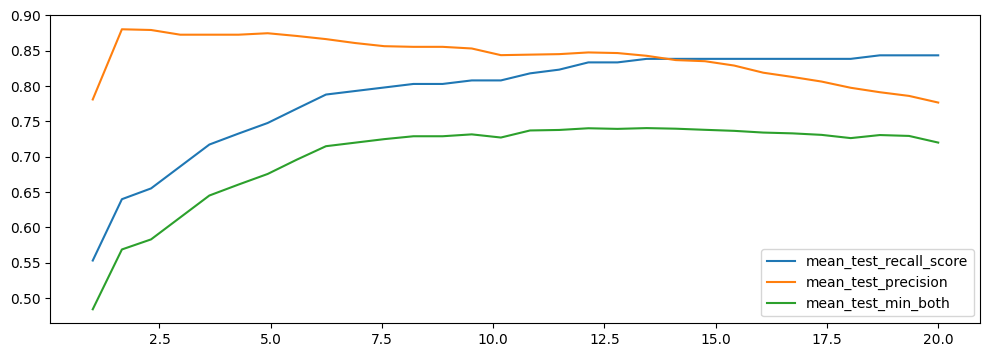

In [59]:
plt.figure(figsize=(12,4))
df1 = pd.DataFrame(grid.cv_results_)

for score in ['mean_test_recall_score', 'mean_test_precision', 'mean_test_min_both']:
    plt.plot(
        [_[1] for _ in df1['param_class_weight']],
        df1[score],
        label = score
    )
plt.legend()

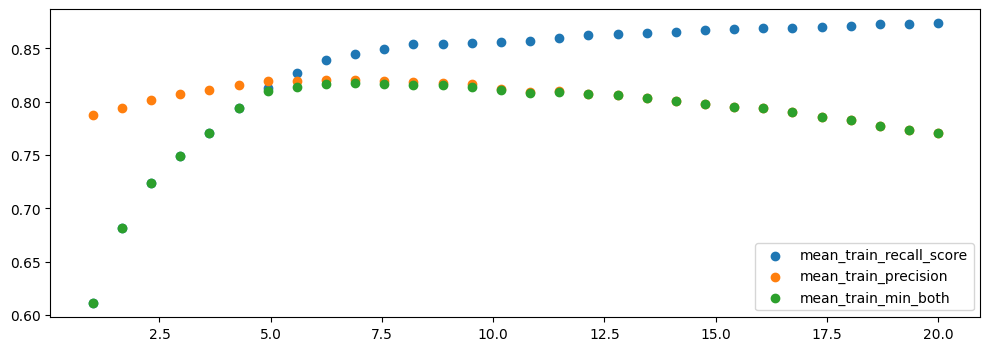

In [60]:
plt.figure(figsize=(12,4))
df1 = pd.DataFrame(grid.cv_results_)

for score in ['mean_train_recall_score', 'mean_train_precision', 'mean_train_min_both']:
    plt.scatter(
        x = [_[1] for _ in df1['param_class_weight']],
        y = df1[score.replace('test', 'train')],
        label = score
    )
plt.legend()